In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

def load_collision_data_multi_year(folder_path: str) -> gpd.GeoDataFrame:

    folder = Path(folder_path)
    files = sorted(folder.glob("*.csv"))

    if not files:
        raise ValueError("No CSV files found in folder")

    print(f"Found {len(files)} files")

    gdfs = []
    for f in files:
        print(f"Loading: {f.name}")
        gdf_year = load_collision_data(str(f))
        gdfs.append(gdf_year)

    gdf = pd.concat(gdfs, ignore_index=True)

    print("Combined shape:", gdf.shape)

    return gdf

In [2]:
def load_collision_data(path: str) -> gpd.GeoDataFrame:
    df = pd.read_csv(path, sep=";", encoding="latin1", low_memory=False)

    df = df.rename(columns={
        "Datum": "datetime",
        "Viltslag": "species",
        "Län": "lan",
        "Kommun": "kommun",
        "Lat WGS84": "lat",
        "Long WGS84": "lon",
    })

    df["lat"] = df["lat"].astype(str).str.replace(",", ".", regex=False)
    df["lon"] = df["lon"].astype(str).str.replace(",", ".", regex=False)

    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
    df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", dayfirst=False)

    df = df.dropna(subset=["datetime", "lat", "lon"]).copy()

    # Keep only plausible Sweden WGS84 coordinates
    df = df[
        df["lat"].between(55, 70) &
        df["lon"].between(10, 25)
    ].copy()

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    ).to_crs("EPSG:3006")

    return gdf

In [3]:
import pandas as pd
from grid import create_grid
from grid import spatial_join_points_to_grid

def build_cell_month_table_full(gdf_points, cell_size=5000):

    # Create grid
    grid = create_grid(gdf_points, cell_size=cell_size)

    # Join points to grid
    joined = spatial_join_points_to_grid(gdf_points, grid)
    joined = joined.dropna(subset=["cell_id"]).copy()
    joined["cell_id"] = joined["cell_id"].astype(int)

    # Month column
    joined["period_start"] = joined["datetime"].dt.to_period("M").dt.to_timestamp()

    # Count collisions per observed cell-month
    observed = (
        joined.groupby(["cell_id", "period_start"])
        .size()
        .reset_index(name="collision_count")
    )

    # Build full set of months in study period
    min_month = gdf_points["datetime"].dt.to_period("M").min().to_timestamp()
    max_month = gdf_points["datetime"].dt.to_period("M").max().to_timestamp()

    all_months = pd.date_range(start=min_month, end=max_month, freq="MS")

    # Build full cell x month panel
    full_index = pd.MultiIndex.from_product(
        [grid["cell_id"].astype(int).unique(), all_months],
        names=["cell_id", "period_start"]
    )

    full_panel = full_index.to_frame(index=False)

    # Merge observed counts into full panel
    cell_month = full_panel.merge(
        observed,
        on=["cell_id", "period_start"],
        how="left"
    )

    cell_month["collision_count"] = cell_month["collision_count"].fillna(0).astype(int)

    # Define high-risk using top 25% of nonzero collision counts
    nonzero_counts = cell_month.loc[cell_month["collision_count"] > 0, "collision_count"]

    if nonzero_counts.empty:
        raise ValueError("No nonzero collision counts found; cannot define high-risk threshold.")

    threshold = nonzero_counts.quantile(0.75)

    cell_month["risk"] = (cell_month["collision_count"] >= threshold).astype(int)

    print("High-risk threshold:", threshold)
    print(cell_month["risk"].value_counts())

    return grid, joined, cell_month

In [4]:
gdf = load_collision_data_multi_year(
    "C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data/Collisions"
)

gdf = gdf[gdf["datetime"].dt.year <= 2025].copy()

print(gdf.shape)
print(gdf["datetime"].min(), "→", gdf["datetime"].max())

print(gdf["datetime"].dt.year.value_counts().sort_index())

grid, joined, cell_month = build_cell_month_table_full(gdf, cell_size=5000) #Vi kan ändra detta beronde på, gjorde den bara lite mindre pga tid

print(cell_month.head())
print(cell_month.shape)
print(cell_month["collision_count"].describe())
print(cell_month["risk"].value_counts())

Found 12 files
Loading: Rådata 2015.csv
Loading: Rådata 2016.csv
Loading: Rådata 2017.csv
Loading: Rådata 2018.csv
Loading: Rådata 2019.csv
Loading: Rådata 2020.csv
Loading: Rådata 2021.csv
Loading: Rådata 2022.csv
Loading: Rådata 2023.csv
Loading: Rådata 2024.csv
Loading: Rådata 2025.csv
Loading: Rådata 2026.csv
Combined shape: (732678, 16)
(712512, 16)
2015-01-01 00:21:00 → 2025-12-31 23:55:00
datetime
2015    44813
2016    56361
2017    58731
2018    63493
2019    64414
2020    62171
2021    68469
2022    67848
2023    71387
2024    77715
2025    77110
Name: count, dtype: int64
High-risk threshold: 2.0
risk
0    5337037
1     164195
Name: count, dtype: int64
   cell_id period_start  collision_count  risk
0        0   2015-01-01                0     0
1        0   2015-02-01                0     0
2        0   2015-03-01                0     0
3        0   2015-04-01                0     0
4        0   2015-05-01                0     0
(5501232, 4)
count    5.501232e+06
mean     1.29

In [5]:
import pandas as pd
import numpy as np

gdf_daylight = load_collision_data("C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data/Collisions/Rådata 2025.csv")
daylight_df = gdf_daylight.copy()
daylight_df["datetime"] = pd.to_datetime(daylight_df["datetime"], errors="coerce")
daylight_df = daylight_df.dropna(subset=["datetime"]).copy()

daylight_df["hour"] = daylight_df["datetime"].dt.hour
daylight_df["month"] = daylight_df["datetime"].dt.month
daylight_df["species"] = daylight_df["species"].astype(str).str.strip().str.lower()

species_map = {
    "älg": "moose",
    "rådjur": "roe_deer",
    "vildsvin": "wild_boar",
    "dovhjort": "fallow_deer",
}
daylight_df["species"] = daylight_df["species"].replace(species_map)

def classify_light_proxy(hour):
    if 5 <= hour < 8:
        return "dawn"
    elif 8 <= hour < 17:
        return "day"
    elif 17 <= hour < 21:
        return "dusk"
    else:
        return "night"

daylight_df["light_condition"] = daylight_df["hour"].apply(classify_light_proxy)

print(daylight_df[["datetime", "hour", "species", "light_condition"]].head())

             datetime  hour    species light_condition
0 2025-01-01 00:15:00     0   roe_deer           night
1 2025-01-01 00:28:00     0  wild_boar           night
2 2025-01-01 00:28:00     0  wild_boar           night
3 2025-01-01 00:58:00     0   roe_deer           night
4 2025-01-01 01:01:00     1   roe_deer           night


In [6]:
light_counts = (
    daylight_df["light_condition"]
    .value_counts()
    .rename_axis("light_condition")
    .reset_index(name="collision_count")
)

light_counts["share"] = light_counts["collision_count"] / light_counts["collision_count"].sum()

print(light_counts)

  light_condition  collision_count     share
0           night            25182  0.326458
1            dusk            19086  0.247430
2             day            18409  0.238653
3            dawn            14460  0.187459


In [7]:
species_light = (
    daylight_df.groupby(["species", "light_condition"])
    .size()
    .reset_index(name="collision_count")
)

species_totals = (
    species_light.groupby("species")["collision_count"]
    .sum()
    .rename("species_total")
    .reset_index()
)

species_light = species_light.merge(species_totals, on="species", how="left")
species_light["share_within_species"] = (
    species_light["collision_count"] / species_light["species_total"]
)

print(species_light.sort_values(["species", "collision_count"], ascending=[True, False]))

        species light_condition  collision_count  species_total  \
2         björn           night                4              8   
0         björn            dawn                2              8   
1         björn            dusk                2              8   
5   fallow_deer            dusk             2160           6820   
4   fallow_deer             day             1936           6820   
6   fallow_deer           night             1546           6820   
3   fallow_deer            dawn             1178           6820   
7          järv            dawn                1              2   
8          järv           night                1              2   
12    kronhjort           night              156            459   
11    kronhjort            dusk              117            459   
9     kronhjort            dawn               97            459   
10    kronhjort             day               89            459   
16           lo           night               22             6

In [8]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

daylight_df["season"] = daylight_df["month"].apply(month_to_season)

season_light = (
    daylight_df.groupby(["season", "light_condition"])
    .size()
    .reset_index(name="collision_count")
)

print(season_light)

    season light_condition  collision_count
0   autumn            dawn             5596
1   autumn             day             5406
2   autumn            dusk             7910
3   autumn           night             6244
4   spring            dawn             3146
5   spring             day             3103
6   spring            dusk             2967
7   spring           night             6636
8   summer            dawn             2437
9   summer             day             4226
10  summer            dusk             1957
11  summer           night             8047
12  winter            dawn             3281
13  winter             day             5674
14  winter            dusk             6252
15  winter           night             4255


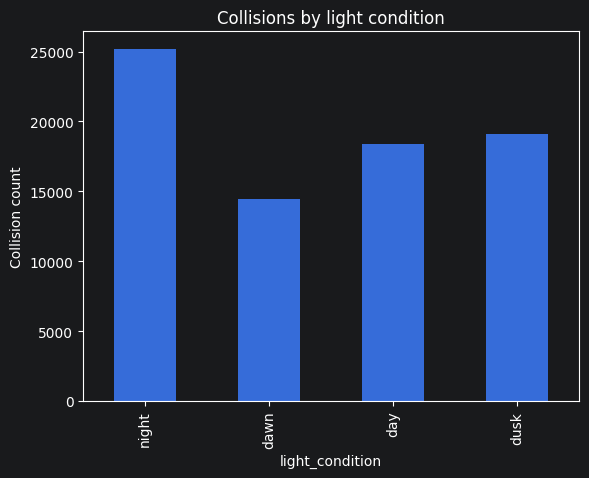

In [9]:
import matplotlib.pyplot as plt

light_counts_plot = daylight_df["light_condition"].value_counts().reindex(
    ["night", "dawn", "day", "dusk"]
)

light_counts_plot.plot(kind="bar")
plt.ylabel("Collision count")
plt.title("Collisions by light condition")
plt.show()

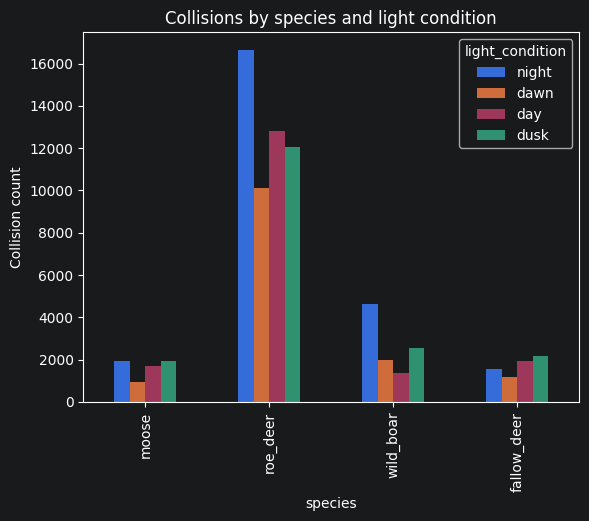

In [10]:
species_order = ["moose", "roe_deer", "wild_boar", "fallow_deer"]

pivot_species_light = (
    daylight_df.groupby(["species", "light_condition"])
    .size()
    .unstack(fill_value=0)
    .reindex(species_order)
)

pivot_species_light = pivot_species_light.reindex(
    columns=["night", "dawn", "day", "dusk"]
)

pivot_species_light.plot(kind="bar")
plt.ylabel("Collision count")
plt.title("Collisions by species and light condition")
plt.show()

In [11]:
df = joined.copy()

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime", "cell_id"]).copy()

df["cell_id"] = df["cell_id"].astype(int)
df["period_start"] = df["datetime"].dt.to_period("M").dt.to_timestamp()
df["hour"] = df["datetime"].dt.hour

def classify_light_proxy(hour):
    if 5 <= hour < 8:
        return "dawn"
    elif 8 <= hour < 17:
        return "day"
    elif 17 <= hour < 21:
        return "dusk"
    else:
        return "night"

df["light_condition"] = df["hour"].apply(classify_light_proxy)

light_counts = (
    df.groupby(["cell_id", "period_start", "light_condition"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

light_cols = [c for c in light_counts.columns if c not in ["cell_id", "period_start"]]

row_sums = light_counts[light_cols].sum(axis=1)
for col in light_cols:
    light_counts[col] = np.where(row_sums > 0, light_counts[col] / row_sums, 0)

light_counts = light_counts.sort_values(["cell_id", "period_start"])

for col in light_cols:
    light_counts[f"{col}_lag1"] = (
        light_counts.groupby("cell_id")[col].shift(1)
    )

lagged_light = light_counts[
    ["cell_id", "period_start"] + [f"{col}_lag1" for col in light_cols]
].fillna(0)

print(lagged_light.head())

light_condition  cell_id period_start  dawn_lag1  day_lag1  dusk_lag1  \
0                     46   2024-10-01        0.0       0.0        0.0   
1                     84   2023-05-01        0.0       0.0        0.0   
2                    327   2024-05-01        0.0       0.0        0.0   
3                    359   2016-09-01        0.0       0.0        0.0   
4                    382   2024-05-01        0.0       0.0        0.0   

light_condition  night_lag1  
0                       0.0  
1                       0.0  
2                       0.0  
3                       0.0  
4                       0.0  


In [12]:

df = joined.copy()

df["period_start"] = df["datetime"].dt.to_period("M").dt.to_timestamp()
df["cell_id"] = df["cell_id"].astype(int)

df["species"] = df["species"].astype(str).str.strip().str.lower()

species_map = {
    "älg": "moose",
    "rådjur": "roe_deer",
    "vildsvin": "wild_boar",
    "dovhjort": "fallow_deer",
}

df["species"] = df["species"].replace(species_map)

relevant_species = ["moose", "roe_deer", "wild_boar", "fallow_deer"]

df = df[df["species"].isin(relevant_species)].copy()

species_counts = (
    df.groupby(["cell_id", "period_start", "species"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

species_counts = species_counts.sort_values(["cell_id", "period_start"])

species_cols = [col for col in species_counts.columns if col not in ["cell_id", "period_start"]]

for col in species_cols:
    species_counts[f"{col}_lag1"] = (
        species_counts.groupby("cell_id")[col].shift(1)
    )

lagged_species = species_counts[
    ["cell_id", "period_start"] + [f"{col}_lag1" for col in species_cols]
].fillna(0)

print(lagged_species.head())

species  cell_id period_start  fallow_deer_lag1  moose_lag1  roe_deer_lag1  \
0             46   2024-10-01               0.0         0.0            0.0   
1             84   2023-05-01               0.0         0.0            0.0   
2            327   2024-05-01               0.0         0.0            0.0   
3            359   2016-09-01               0.0         0.0            0.0   
4            382   2024-05-01               0.0         0.0            0.0   

species  wild_boar_lag1  
0                   0.0  
1                   0.0  
2                   0.0  
3                   0.0  
4                   0.0  


In [13]:
from roads import build_road_features, load_roads_for_study_area, load_roads

roads = load_roads_for_study_area(
    path="C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data/Sverige_Vägtrafiknät_GeoPackage/Sverige_Vägtrafiknät_194602.gpkg",
    gdf_points=gdf,
    buffer_m=2000
)

road_features = build_road_features(
    grid=grid,
    roads=roads,
    keep_only_classes=["bilnät"] #doesnt work lol
)

model_df = cell_month.merge(
    road_features.drop(columns="geometry"),
    on="cell_id",
    how="left"
)

model_df = model_df[model_df["road_length_m"] > 0].copy()

print(model_df.shape)
print(model_df["risk"].value_counts())
print(model_df[["road_length_m", "road_density", "nearest_road_distance_m"]].describe())

(2174700, 9)
risk
0    2009637
1     165063
Name: count, dtype: int64
       road_length_m  road_density  nearest_road_distance_m
count   2.174700e+06  2.174700e+06             2.174700e+06
mean    3.960343e+04  1.584137e-03             4.391375e+02
std     2.887192e+04  1.154877e-03             5.897063e+02
min     5.866782e+00  2.346713e-07             9.774112e-03
25%     2.138851e+04  8.555404e-04             9.162207e+01
50%     3.424963e+04  1.369985e-03             2.261651e+02
75%     5.368897e+04  2.147559e-03             4.898364e+02
max     4.221471e+05  1.688589e-02             3.490548e+03


In [14]:
from roads import load_linear_layer_for_study_area, build_linear_features

railways = load_linear_layer_for_study_area(
    path="C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data/Järnvägnät_grundegenskaper/Järnvägsnät_grundegenskaper3_0_GeoPackage.gpkg",
    gdf_points=gdf,
    buffer_m=2000
)

rail_features = build_linear_features(
    grid=grid,
    lines=railways,
    prefix="rail"
)

model_df = model_df.merge(
    rail_features.drop(columns=["geometry", "cell_area_m2"], errors="ignore"),
    on="cell_id",
    how="left"
)

for col in ["rail_length_m", "rail_density", "nearest_rail_distance_m"]:
    model_df[col] = model_df[col].fillna(0)

model_df["rail_near_10km"] = (
    model_df["nearest_rail_distance_m"] < 10000
).astype(int)


In [15]:
from roads import load_linear_layer_for_study_area, build_linear_features

fences = load_linear_layer_for_study_area(
    path="C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data/Barrairanalys/Barriaranalys.gpkg",
    gdf_points=gdf,
    buffer_m=2000,
    layer="barriarer_kvarvarande_vag"
)

fence_features = build_linear_features(
    grid=grid,
    lines=fences,
    prefix="fence"
)

model_df = model_df.merge(
    fence_features.drop(columns=["geometry", "cell_area_m2"], errors="ignore"),
    on="cell_id",
    how="left"
)

for col in ["fence_length_m", "fence_density", "nearest_fence_distance_m"]:
    model_df[col] = model_df[col].fillna(0)

# Create proximity feature
model_df["fence_near_10km"] = (
    model_df["nearest_fence_distance_m"] < 10000
).astype(int)

#print(fence_features[["fence_length_m", "fence_density", "nearest_fence_distance_m"]].describe())
print(model_df["fence_near_10km"].value_counts())
print(model_df["fence_near_10km"].value_counts(normalize=True))

fence_near_10km
0    1292676
1     906048
Name: count, dtype: int64
fence_near_10km
0    0.587921
1    0.412079
Name: proportion, dtype: float64


In [16]:
relevant_cell_ids = model_df["cell_id"].unique()
grid_small = grid[grid["cell_id"].isin(relevant_cell_ids)].copy()

print("Original grid:", grid.shape)
print("Filtered grid:", grid_small.shape)

Original grid: (41676, 2)
Filtered grid: (16396, 2)


In [17]:
from weather import build_cell_month_temperature

temperature_features = build_cell_month_temperature(grid=grid_small)

model_df = model_df.merge(
    temperature_features[["cell_id", "period_start", "temp_mean", "temp_min", "temp_max"]],
    on=["cell_id", "period_start"],
    how="left"
)

model_df = model_df.dropna(subset=["temp_mean", "temp_min", "temp_max"]).copy()

model_df = model_df.merge(
    lagged_species,
    on=["cell_id", "period_start"],
    how="left"
)

lag_cols = ["moose_lag1", "roe_deer_lag1", "wild_boar_lag1", "fallow_deer_lag1"]

for col in lag_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(0)

model_df = model_df.merge(
    lagged_light,
    on=["cell_id", "period_start"],
    how="left"
)

light_lag_cols = [c for c in lagged_light.columns if c not in ["cell_id", "period_start"]]
for col in light_lag_cols:
    model_df[col] = model_df[col].fillna(0)

C:\Users\Amanda\PycharmProjects\thesis_boogaloo\src\weather.py:131: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids["geometry"] = centroids.geometry.centroid


Parsed columns for station 72500: ['Datum', 'Tid (UTC)', 'Lufttemperatur', 'Kvalitet', 'Unnamed: 4', 'Tidsutsnitt:']
date_col: Datum
time_col: Tid (UTC)
temp_col: Lufttemperatur
Metadata request failed for station 11032: 404
Parsed columns for station 84140: ['Datum', 'Tid (UTC)', 'Lufttemperatur', 'Kvalitet', 'Unnamed: 4', 'Tidsutsnitt:']
date_col: Datum
time_col: Tid (UTC)
temp_col: Lufttemperatur
Parsed columns for station 125490: ['Datum', 'Tid (UTC)', 'Lufttemperatur', 'Kvalitet', 'Unnamed: 4', 'Tidsutsnitt:']
date_col: Datum
time_col: Tid (UTC)
temp_col: Lufttemperatur
Parsed columns for station 162015: ['Datum', 'Tid (UTC)', 'Lufttemperatur', 'Kvalitet', 'Unnamed: 4', 'Tidsutsnitt:']
date_col: Datum
time_col: Tid (UTC)
temp_col: Lufttemperatur


In [18]:
import numpy as np

model_df["month"] = model_df["period_start"].dt.month
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)
model_df["is_hunting_season"] = model_df["month"].isin([10, 11]).astype(int)

features = [
    "road_length_m",
    "road_density",
    "nearest_road_distance_m",

    "rail_length_m",
    "rail_density",
    "rail_near_10km",

    "fence_length_m",
    "fence_density",
    "fence_near_10km",

    "temp_mean",
    "temp_min",
    "temp_max",

    "moose_lag1",
    "roe_deer_lag1",
    "wild_boar_lag1",
    "fallow_deer_lag1",

    "night_lag1",
    "dawn_lag1",
    "day_lag1",
    "dusk_lag1",

    "month_sin",
    "month_cos",
    "is_hunting_season",
]
model_df_clean = model_df.dropna(subset=features).copy()

print("After dropna:", model_df_clean.shape)
print(model_df_clean["period_start"].value_counts().sort_index())

After dropna: (613901, 32)
period_start
2015-01-01    4962
2015-02-01    4963
2015-03-01    4927
2015-04-01    4936
2015-05-01    4947
              ... 
2025-08-01    4437
2025-09-01    4415
2025-10-01    4438
2025-11-01    4446
2025-12-01    4422
Name: count, Length: 132, dtype: int64


In [19]:
months = sorted(model_df_clean["period_start"].unique())
print(months)

train_months = months[:-1]
test_months = months[-1:]

train = model_df_clean[model_df_clean["period_start"].isin(train_months)].copy()
test = model_df_clean[model_df_clean["period_start"].isin(test_months)].copy()

X_train = train[features]
y_train = train["risk"]

X_test = test[features]
y_test = test["risk"]

print("train shape:", X_train.shape)
print("test shape:", X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())


[Timestamp('2015-01-01 00:00:00'), Timestamp('2015-02-01 00:00:00'), Timestamp('2015-03-01 00:00:00'), Timestamp('2015-04-01 00:00:00'), Timestamp('2015-05-01 00:00:00'), Timestamp('2015-06-01 00:00:00'), Timestamp('2015-07-01 00:00:00'), Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-01 00:00:00'), Timestamp('2015-10-01 00:00:00'), Timestamp('2015-11-01 00:00:00'), Timestamp('2015-12-01 00:00:00'), Timestamp('2016-01-01 00:00:00'), Timestamp('2016-02-01 00:00:00'), Timestamp('2016-03-01 00:00:00'), Timestamp('2016-04-01 00:00:00'), Timestamp('2016-05-01 00:00:00'), Timestamp('2016-06-01 00:00:00'), Timestamp('2016-07-01 00:00:00'), Timestamp('2016-08-01 00:00:00'), Timestamp('2016-09-01 00:00:00'), Timestamp('2016-10-01 00:00:00'), Timestamp('2016-11-01 00:00:00'), Timestamp('2016-12-01 00:00:00'), Timestamp('2017-01-01 00:00:00'), Timestamp('2017-02-01 00:00:00'), Timestamp('2017-03-01 00:00:00'), Timestamp('2017-04-01 00:00:00'), Timestamp('2017-05-01 00:00:00'), Timestamp('20

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

logreg_pipeline.fit(X_train, y_train)

y_pred = logreg_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95      4068
           1       0.46      1.00      0.63       354

    accuracy                           0.90      4422
   macro avg       0.73      0.95      0.79      4422
weighted avg       0.96      0.90      0.92      4422



In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      4068
           1       0.69      0.54      0.60       354

    accuracy                           0.94      4422
   macro avg       0.82      0.76      0.79      4422
weighted avg       0.94      0.94      0.94      4422



In [25]:
from sklearn.metrics import roc_auc_score

y_prob_lr = logreg_pipeline.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("LR AUC:", roc_auc_score(y_test, y_prob_lr))
print("RF AUC:", roc_auc_score(y_test, y_prob_rf))

LR AUC: 0.9727242804526439
RF AUC: 0.9713639318034099


In [23]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance)

roe_deer_lag1              0.254460
road_density               0.133616
road_length_m              0.102499
night_lag1                 0.071109
fence_near_10km            0.060353
dusk_lag1                  0.044514
day_lag1                   0.038513
fence_length_m             0.036906
dawn_lag1                  0.031971
fence_density              0.030156
moose_lag1                 0.026163
temp_mean                  0.023907
wild_boar_lag1             0.023901
temp_min                   0.023843
temp_max                   0.023018
nearest_road_distance_m    0.019816
rail_near_10km             0.010852
fallow_deer_lag1           0.010416
rail_density               0.009554
month_cos                  0.007758
rail_length_m              0.007636
month_sin                  0.007547
is_hunting_season          0.001492
dtype: float64


In [24]:
model_df_clean.to_csv("C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data/processed/model_df_clean_2025.csv", index=False)